Radial Basis Function Network (RBFN) — Function Approximation & Classification

In [3]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


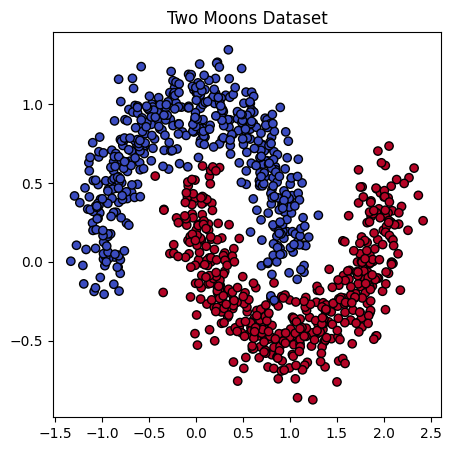

In [4]:
# CELL 2 — Generate dataset (two interleaving moons — non-linearly separable)
# RBFNs excel here because Gaussian "bumps" naturally carve out curved decision regions
X, y = make_moons(n_samples=1000, noise=0.15, random_state=42)

plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Two Moons Dataset")
plt.show()

In [5]:
# CELL 3 — Train/test split, scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

print(X_train_t.shape, y_train_t.shape)

torch.Size([800, 2]) torch.Size([800, 1])


Number of centers: 20 | Sigma: 0.2832


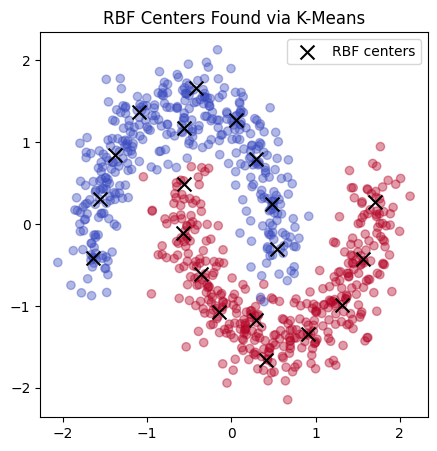

In [6]:
# CELL 4 — Choose RBF centers via k-means (standard RBFN initialization)
num_centers = 20
kmeans = KMeans(n_clusters=num_centers, random_state=42, n_init=10)
kmeans.fit(X_train)
centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

# Estimate a shared width (sigma) from the average distance between centers
from scipy.spatial.distance import pdist
center_distances = pdist(kmeans.cluster_centers_)
sigma = center_distances.mean() / np.sqrt(2 * num_centers)
print(f"Number of centers: {num_centers} | Sigma: {sigma:.4f}")

plt.figure(figsize=(5, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.4)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c="black", marker="x", s=100, label="RBF centers")
plt.legend()
plt.title("RBF Centers Found via K-Means")
plt.show()

In [7]:
# CELL 5 — Model definition
class RBFLayer(nn.Module):
    """Computes Gaussian radial basis activations for each center."""
    def __init__(self, centers, sigma):
        super().__init__()
        self.centers = nn.Parameter(centers, requires_grad=True)  # allow fine-tuning
        self.sigma = nn.Parameter(torch.tensor(sigma, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        # x: [batch, input_dim] | centers: [num_centers, input_dim]
        x_expanded = x.unsqueeze(1)                      # [batch, 1, input_dim]
        centers_expanded = self.centers.unsqueeze(0)      # [1, num_centers, input_dim]
        distances_sq = ((x_expanded - centers_expanded) ** 2).sum(dim=2)  # [batch, num_centers]
        return torch.exp(-distances_sq / (2 * self.sigma ** 2))  # Gaussian RBF activation

class RBFNetwork(nn.Module):
    def __init__(self, centers, sigma, output_dim=1):
        super().__init__()
        self.rbf = RBFLayer(centers, sigma)
        self.linear = nn.Linear(centers.shape[0], output_dim)  # linear combination of RBF outputs

    def forward(self, x):
        phi = self.rbf(x)          # Gaussian "bump" activations per center
        return self.linear(phi)    # raw logit — weighted sum of bumps

model = RBFNetwork(centers, sigma).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

RBFNetwork(
  (rbf): RBFLayer()
  (linear): Linear(in_features=20, out_features=1, bias=True)
)


In [8]:
# CELL 6 — Training loop
epochs = 300
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1}/{epochs} — Loss: {loss.item():.4f}")

Epoch 30/300 — Loss: 0.3964
Epoch 60/300 — Loss: 0.2657
Epoch 90/300 — Loss: 0.2186
Epoch 120/300 — Loss: 0.1766
Epoch 150/300 — Loss: 0.1440
Epoch 180/300 — Loss: 0.1209
Epoch 210/300 — Loss: 0.1041
Epoch 240/300 — Loss: 0.0915
Epoch 270/300 — Loss: 0.0817
Epoch 300/300 — Loss: 0.0739


In [9]:
# CELL 7 — Evaluation
model.eval()
with torch.no_grad():
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float()
    accuracy = (test_preds == y_test_t).float().mean().item()
    print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 99.50%


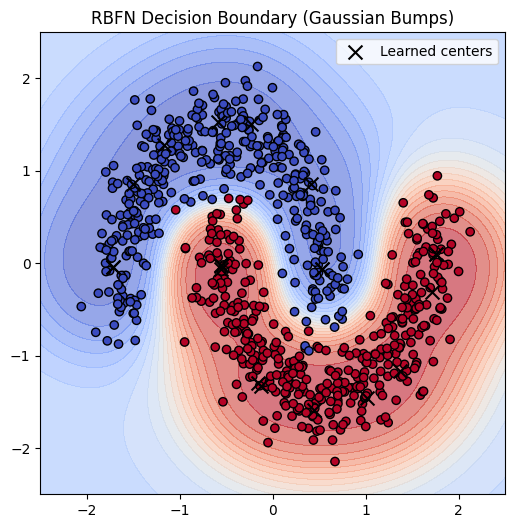

In [10]:
# CELL 8 — Visualize the learned decision boundary (shows the Gaussian "bumps" effect)
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
grid_t = torch.tensor(grid).to(device)

model.eval()
with torch.no_grad():
    grid_probs = torch.sigmoid(model(grid_t)).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, grid_probs, levels=20, cmap="coolwarm", alpha=0.6)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolors="k")
learned_centers = model.rbf.centers.detach().cpu().numpy()
plt.scatter(learned_centers[:, 0], learned_centers[:, 1], c="black", marker="x", s=100, label="Learned centers")
plt.legend()
plt.title("RBFN Decision Boundary (Gaussian Bumps)")
plt.show()